In [34]:
# Import all libraries.
import os
import numpy as np
import pandas as pd
import json 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [35]:
# Initialize Pandas settings.
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option("display.expand_frame_repr", False)

In [36]:
# Enforce reproducablity.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [37]:
from sentence_transformers import SentenceTransformer
# model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
model = SentenceTransformer("all-mpnet-base-v2")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6326.06it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
# # Using Google Colab:
# from google.colab import drive
# drive.mount('/content/drive/')

# DATA_DIR = "/content/drive/MyDrive/CS 489" 
# FILE = os.path.join(DATA_DIR, "CS 489 - Self Playing - Data Collection (1).csv")

# Using local directories:
DATA_DIR = "/Users/xmastersteel/wally/dl" 
FILE = os.path.join(DATA_DIR, "/Users/xmastersteel/wally/dl/data/CS 489 - Self Playing (New).csv")


In [39]:

# Separate dataset into 75/10/15 split.
TRAIN_SPLIT = 0.75 
VAL_SPLIT   = 0.10
TEST_SPLIT  = 0.15
df          = pd.read_csv(FILE)
train_parts, val_parts, test_parts = [], [], []

# Scan through all unique word pairs (30).
for pair_id, group in df.groupby("anchor_left (0)"):
    
    # Extract 15% of total dataset into test set. 
    train_and_val, test = train_test_split(
        group, test_size = TEST_SPLIT, random_state = RANDOM_SEED)
    
    # Extract 10% of remaining 85% for validation split.
    train, val = train_test_split(
        train_and_val, test_size = VAL_SPLIT / (1 - TEST_SPLIT), random_state = RANDOM_SEED)

    train_parts.append(train)
    val_parts.append(val)
    test_parts.append(test)

# Turn train/val/test sets back into singular dfs.
train_df = pd.concat(train_parts).reset_index(drop = True)
val_df   = pd.concat(val_parts).reset_index(drop = True)
test_df  = pd.concat(test_parts).reset_index(drop = True)

print(train_df)
print(val_df)
print(test_df)


         anchor_left (0)  anchor_right (100)                      clue  target               response_list  response_mean  difference    category  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11 Unnamed: 12
0                    Bad                Good           Cutting in line    34.0            33, 27, 12, 8, 8          17.60       16.40  Subjective         NaN         NaN          NaN          NaN         NaN
1                    Bad                Good            Curing disease    91.0          92, 90, 98, 97, 98          95.00        4.00  Subjective         NaN         NaN          NaN          NaN         NaN
2                    Bad                Good        Fostering children    70.0          90, 90, 90, 90, 88          89.60       19.60  Subjective         NaN         NaN          NaN          NaN         NaN
3                    Bad                Good         Community service    76.0          75, 84, 88, 88, 88          84.60        8.60  Subjective         NaN         Na

In [40]:

def cosine_similarity(a, b):
    dot    = np.sum(a * b, axis = 1)
    norm_a = np.linalg.norm(a, axis = 1)
    norm_b = np.linalg.norm(b, axis = 1)
    return dot / (norm_a * norm_b)

def semantic_axis_score(left_enc, right_enc, clue_enc):
    axis          = right_enc - left_enc
    clue_relative = clue_enc  - left_enc
    axis_norm_sq  = np.sum(axis ** 2, axis = 1)
    t             = np.sum(clue_relative * axis, axis = 1) / axis_norm_sq
    return t

# Extract strings from train df.
left_words  = np.array(train_df.loc[:, "anchor_left (0)"])
right_words = np.array(train_df.loc[:, "anchor_right (100)"])
clue_words  = np.array(train_df.loc[:, "clue"])

# Clean NaN values.
left_words  = np.array([str(w) if isinstance(w, str) else "" for w in left_words])
right_words = np.array([str(w) if isinstance(w, str) else "" for w in right_words])
clue_words  = np.array([str(w) if isinstance(w, str) else "" for w in clue_words])

# Richer prompt templates.
left_prompts  = "Something that is clearly " + left_words  + " in nature"
right_prompts = "Something that is clearly " + right_words + " in nature"
clue_prompts  = "The concept or activity known as: "        + clue_words

# Encode strings numerically via sentence transformer.
left_enc  = model.encode(left_prompts,  normalize_embeddings = True)
right_enc = model.encode(right_prompts, normalize_embeddings = True)
clue_enc  = model.encode(clue_prompts,  normalize_embeddings = True)

# Cosine similarities.
left_cos_sim  = cosine_similarity(left_enc,  clue_enc)
right_cos_sim = cosine_similarity(right_enc, clue_enc)

# Improved scores.
delta  = right_cos_sim - left_cos_sim        
scores = semantic_axis_score(left_enc, right_enc, clue_enc)  

for lword, rword, clue, lcs, rcs, d, s in zip(
    left_words, right_words, clue_words,
    left_cos_sim, right_cos_sim, delta, scores
):
    print(f"\n{lword} / {rword} -- {clue}")
    print(f"  left_cos: {lcs:.4f} | right_cos: {rcs:.4f} | delta: {d:.4f} | axis_score: {s:.4f}")


Bad / Good -- Cutting in line
  left_cos: 0.1694 | right_cos: 0.0737 | delta: -0.0957 | axis_score: 0.3476

Bad / Good -- Curing disease
  left_cos: 0.2235 | right_cos: 0.2697 | delta: 0.0462 | axis_score: 0.5736

Bad / Good -- Fostering children
  left_cos: 0.1912 | right_cos: 0.1593 | delta: -0.0319 | axis_score: 0.4491

Bad / Good -- Community service
  left_cos: 0.1506 | right_cos: 0.1644 | delta: 0.0138 | axis_score: 0.5220

Bad / Good -- Selfless heroism
  left_cos: 0.1132 | right_cos: 0.1201 | delta: 0.0068 | axis_score: 0.5108

Bad / Good -- Forgetting birthdays
  left_cos: 0.1337 | right_cos: -0.0053 | delta: -0.1390 | axis_score: 0.2787

Bad / Good -- Feeding homeless
  left_cos: 0.2075 | right_cos: 0.1781 | delta: -0.0294 | axis_score: 0.4532

Bad / Good -- Adopting a pet
  left_cos: 0.2185 | right_cos: 0.1607 | delta: -0.0578 | axis_score: 0.4079

Bad / Good -- Helping a stranger
  left_cos: 0.1633 | right_cos: 0.1510 | delta: -0.0123 | axis_score: 0.4804

Bad / Good -- Th

In [41]:
def axis_projection_predict(left_enc, right_enc, clue_enc):
    axis       = right_enc - left_enc         
    clue_shift = clue_enc  - left_enc          
    proj = np.sum(clue_shift * axis, axis = 1) / (np.linalg.norm(axis, axis = 1) ** 2 + 1e-8)
    return np.clip(proj, 0, 1) * 100

def cos_prediction(left_sim, right_sim):
    total = left_sim + right_sim
    return (right_sim / total) * 100

cos_predictions = cos_prediction(left_cos_sim, right_cos_sim)
cos_mae = np.mean(np.abs(cos_predictions - pd.to_numeric(train_df["response_mean"], errors = "coerce")))
print(f"Baseline MAE (Cosine): {cos_mae:.2f}")

axis_predictions = axis_projection_predict(left_enc, right_enc, clue_enc)
axis_mae = np.mean(np.abs(axis_predictions - pd.to_numeric(train_df["response_mean"], errors = "coerce")))
print(f"Baseline MAE (Axis-Projection): {axis_mae:.2f}")

Baseline MAE (Cosine): 28.57
Baseline MAE (Axis-Projection): 25.86


In [42]:
# Ranges I extracted from physical Wavelength game.
BLUE_RANGE_MAE   = 3.1
ORANGE_RANGE_MAE = 9.4
YELLOW_RANGE_MAE = 15.5

actual      = pd.to_numeric(train_df["response_mean"], errors = "coerce")
cos_errors  = np.abs(cos_predictions  - actual)
axis_errors = np.abs(axis_predictions - actual)
total       = len(actual)

# Cosine Simlilarity Metrics:
cos_within_blue    = np.sum(cos_errors  <= BLUE_RANGE_MAE)
cos_within_orange  = np.sum(cos_errors  <= ORANGE_RANGE_MAE)
cos_within_yellow  = np.sum(cos_errors  <= YELLOW_RANGE_MAE)
cos_within_blue_acc   = cos_within_blue   / total * 100
cos_within_orange_acc = cos_within_orange / total * 100
cos_within_yellow_acc = cos_within_yellow / total * 100

# Axis Projection Metrics:
axis_within_blue   = np.sum(axis_errors <= BLUE_RANGE_MAE)
axis_within_orange = np.sum(axis_errors <= ORANGE_RANGE_MAE)
axis_within_yellow = np.sum(axis_errors <= YELLOW_RANGE_MAE)
axis_within_blue_acc   = axis_within_blue   / total * 100
axis_within_orange_acc = axis_within_orange / total * 100
axis_within_yellow_acc = axis_within_yellow / total * 100

# Print Cosine and Axis metrics.
for name, wb, wo, wy, wba, woa, wya in [
    ("Cosine",          cos_within_blue,  cos_within_orange,  cos_within_yellow,  cos_within_blue_acc,  cos_within_orange_acc,  cos_within_yellow_acc),
    ("Axis-Projection", axis_within_blue, axis_within_orange, axis_within_yellow, axis_within_blue_acc, axis_within_orange_acc, axis_within_yellow_acc),
]:
    print(f"\n{name}:")
    print(f"  Within Blue   (<= {BLUE_RANGE_MAE}):  {wb}/{total} ({wba}%)")
    print(f"  Within Orange (<= {ORANGE_RANGE_MAE}):  {wo}/{total} ({woa}%)")
    print(f"  Within Yellow (<= {YELLOW_RANGE_MAE}): {wy}/{total} ({wya}%)")


Cosine:
  Within Blue   (<= 3.1):  37/1110 (3.3333333333333335%)
  Within Orange (<= 9.4):  104/1110 (9.36936936936937%)
  Within Yellow (<= 15.5): 194/1110 (17.47747747747748%)

Axis-Projection:
  Within Blue   (<= 3.1):  65/1110 (5.8558558558558556%)
  Within Orange (<= 9.4):  214/1110 (19.27927927927928%)
  Within Yellow (<= 15.5): 344/1110 (30.99099099099099%)


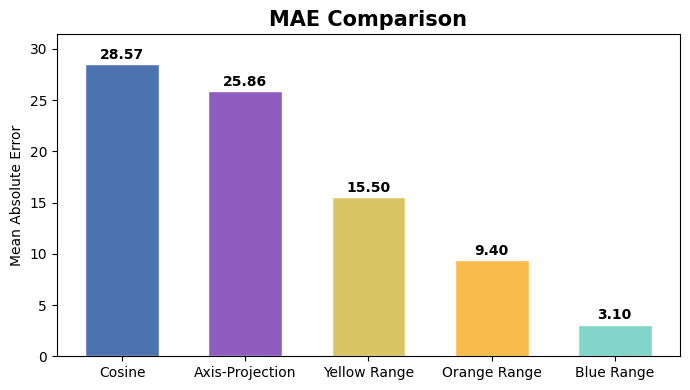

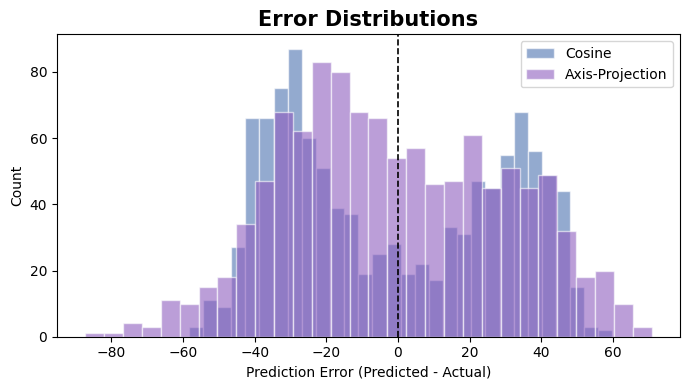

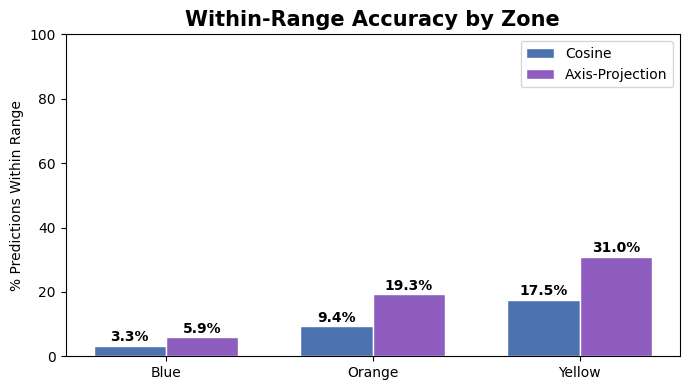

In [43]:
# Add new dir, if it doesn't already exist.
os.makedirs("graphs/baseline", exist_ok = True)


# MAE Loss Graph:
plt.figure(figsize = (7, 4))
bars = plt.bar(["Cosine", "Axis-Projection", "Yellow Range", "Orange Range", "Blue Range"], 
               [cos_mae, axis_mae, YELLOW_RANGE_MAE, ORANGE_RANGE_MAE, BLUE_RANGE_MAE],
               color = ["#4C72B0", "#8E5DBF", "#D9C563", "#F9BC4C", "#82D5C9"], width = 0.6, edgecolor = "white")

for bar, val in zip(bars, [cos_mae, axis_mae, YELLOW_RANGE_MAE, ORANGE_RANGE_MAE, BLUE_RANGE_MAE]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f"{val:.2f}", ha = "center", va = "bottom", fontweight = "bold")

plt.ylabel("Mean Absolute Error")
plt.title("MAE Comparison", fontsize = 15, fontweight = 'bold')
plt.ylim(0, max(cos_mae, axis_mae) * 1.1)
plt.savefig("graphs/baseline/mae_loss.png")
plt.tight_layout()
plt.show()


# MAE Errors Distribution Graph:
cos_errors  = cos_predictions  - pd.to_numeric(train_df["response_mean"], errors = "coerce")
axis_errors = axis_predictions - pd.to_numeric(train_df["response_mean"], errors = "coerce")

# Trim out any outliers, no stretch graph.
cos_clean  = cos_errors[np.abs(cos_errors)   < 3 * np.std(cos_errors)]
axis_clean = axis_errors[np.abs(axis_errors) < 3 * np.std(axis_errors)]

plt.figure(figsize = (7, 4))
plt.hist(cos_clean,  bins = 30, color = "#4C72B0", alpha = 0.6, label = "Cosine",          edgecolor = "white")
plt.hist(axis_clean, bins = 30, color = "#8E5DBF", alpha = 0.6, label = "Axis-Projection", edgecolor = "white")
plt.axvline(0, color = "black", lw = 1.2, linestyle = "--")
plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Count")
plt.title("Error Distributions", fontsize = 15, fontweight = 'bold')
plt.legend()
plt.savefig("graphs/baseline/mae_error_distribution.png")
plt.tight_layout()
plt.show()


# Within Range Accuracy Graph:
labels   = ["Blue", "Orange", "Yellow"]
x        = np.arange(len(labels))
width    = 0.35

cos_acc  = [cos_within_blue_acc,  cos_within_orange_acc,  cos_within_yellow_acc]
axis_acc = [axis_within_blue_acc, axis_within_orange_acc, axis_within_yellow_acc]

plt.figure(figsize = (7, 4))
bars1 = plt.bar(x - width / 2, cos_acc,  width, label = "Cosine",          color = "#4C72B0", edgecolor = "white")
bars2 = plt.bar(x + width / 2, axis_acc, width, label = "Axis-Projection", color = "#8E5DBF", edgecolor = "white")

for bar in bars1 + bars2:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}%", ha = "center", va = "bottom", fontweight = "bold")

plt.xticks(x, labels)
plt.ylabel("% Predictions Within Range")
plt.title("Within-Range Accuracy by Zone", fontsize = 15, fontweight = 'bold')
plt.ylim(0, 100)
plt.legend()
plt.savefig("graphs/baseline/within_range_accuracy.png")
plt.tight_layout()
plt.show()

In [44]:
baseline_history = {
    "cos_mae":  float(cos_mae),
    "axis_mae": float(axis_mae),
    "wavelength_ranges": {
        "blue_range_mae":   BLUE_RANGE_MAE,
        "orange_range_mae": ORANGE_RANGE_MAE,
        "yellow_range_mae": YELLOW_RANGE_MAE
    },
    "within_range": {
        "cos": {
            "blue":   float(cos_within_blue_acc),
            "orange": float(cos_within_orange_acc),
            "yellow": float(cos_within_yellow_acc),
        },
        "axis": {
            "blue":   float(axis_within_blue_acc),
            "orange": float(axis_within_orange_acc),
            "yellow": float(axis_within_yellow_acc),
        }
    },
    "cos_predictions":  cos_predictions.tolist(),
    "axis_predictions": axis_predictions.tolist(),
    "cos_errors":       cos_errors.tolist(),
    "axis_errors":      axis_errors.tolist()
}


OUTPUT_PATH = "history/baseline/"
os.makedirs(OUTPUT_PATH, exist_ok = True)
with open(OUTPUT_PATH + "baseline.json", "w") as f:
    json.dump(baseline_history, f, indent = 4)

print(f"Saved to {OUTPUT_PATH + "baseline.json"}")

Saved to history/baseline/baseline.json
